# Revenue Deep Dive

Source: sales_clean.parquet, customers_clean.parquet, products_clean.parquet

Covers: revenue by customer segment, product segment, channel, geography, seasonality

### Imports

In [1]:
import pandas as pd
from src.analysis import revenue as revenue_analysis
from src.viz import base

### Load Data

In [2]:
sales     = pd.read_parquet("../data/processed/sales_clean.parquet")
customers = pd.read_parquet("../data/processed/customers_clean.parquet")
products  = pd.read_parquet("../data/processed/products_clean.parquet")

print("sales   :", sales.shape)
print("customers:", customers.shape)
print("products :", products.shape)

sales   : (62884, 19)
customers: (15266, 12)
products : (2517, 13)


## Revenue by Customer Age Group

,Age Group,Revenue USD
4,65+,22223426.33
2,35-49,13114033.00
3,50-64,12515383.38
1,25-34,8786282.12
0,<25,892213.63


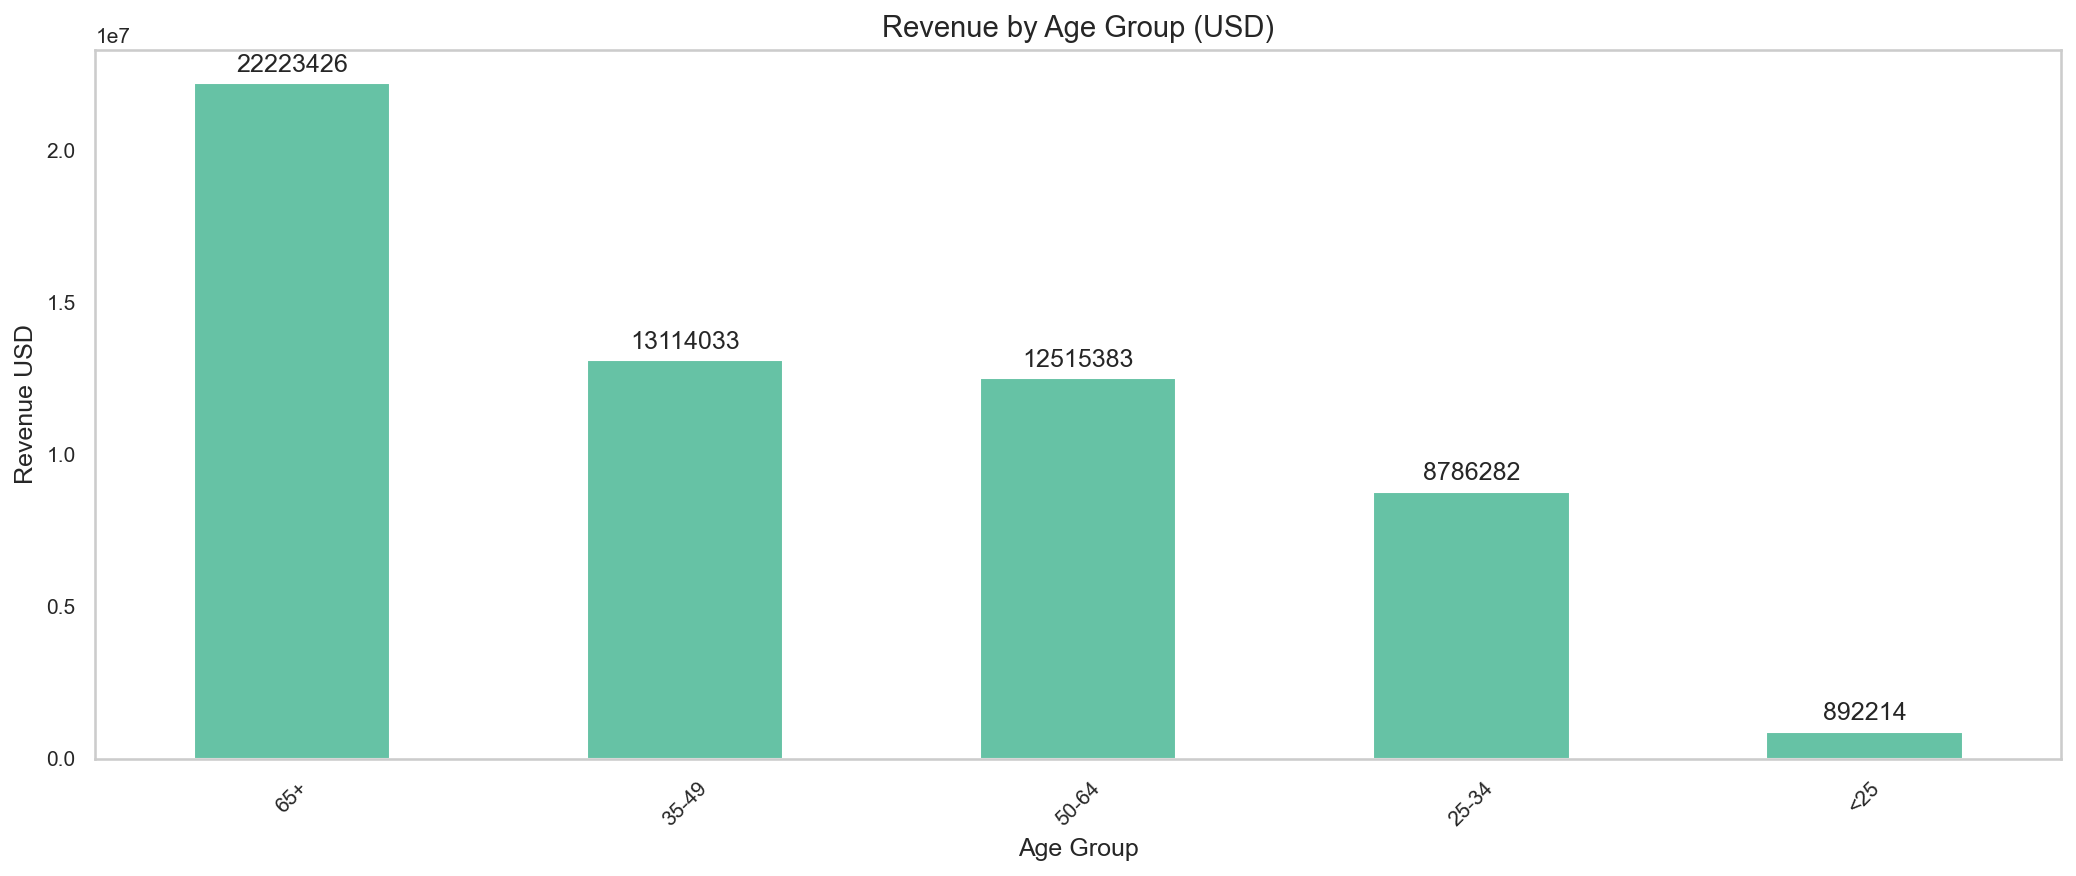

In [3]:
by_age = revenue_analysis.revenue_by_age_group(sales, customers)
display(by_age)
fig, ax = base.bar(
    by_age.set_index("Age Group")["Revenue USD"],
    title="Revenue by Age Group (USD)",
    xlabel="Age Group",
    ylabel="Revenue USD",
    filename="revenue_by_age_group.png"
)

display(fig)

## Revenue by Gender

,Gender,Revenue USD
0,Female,28291900.38
1,Male,29239438.08


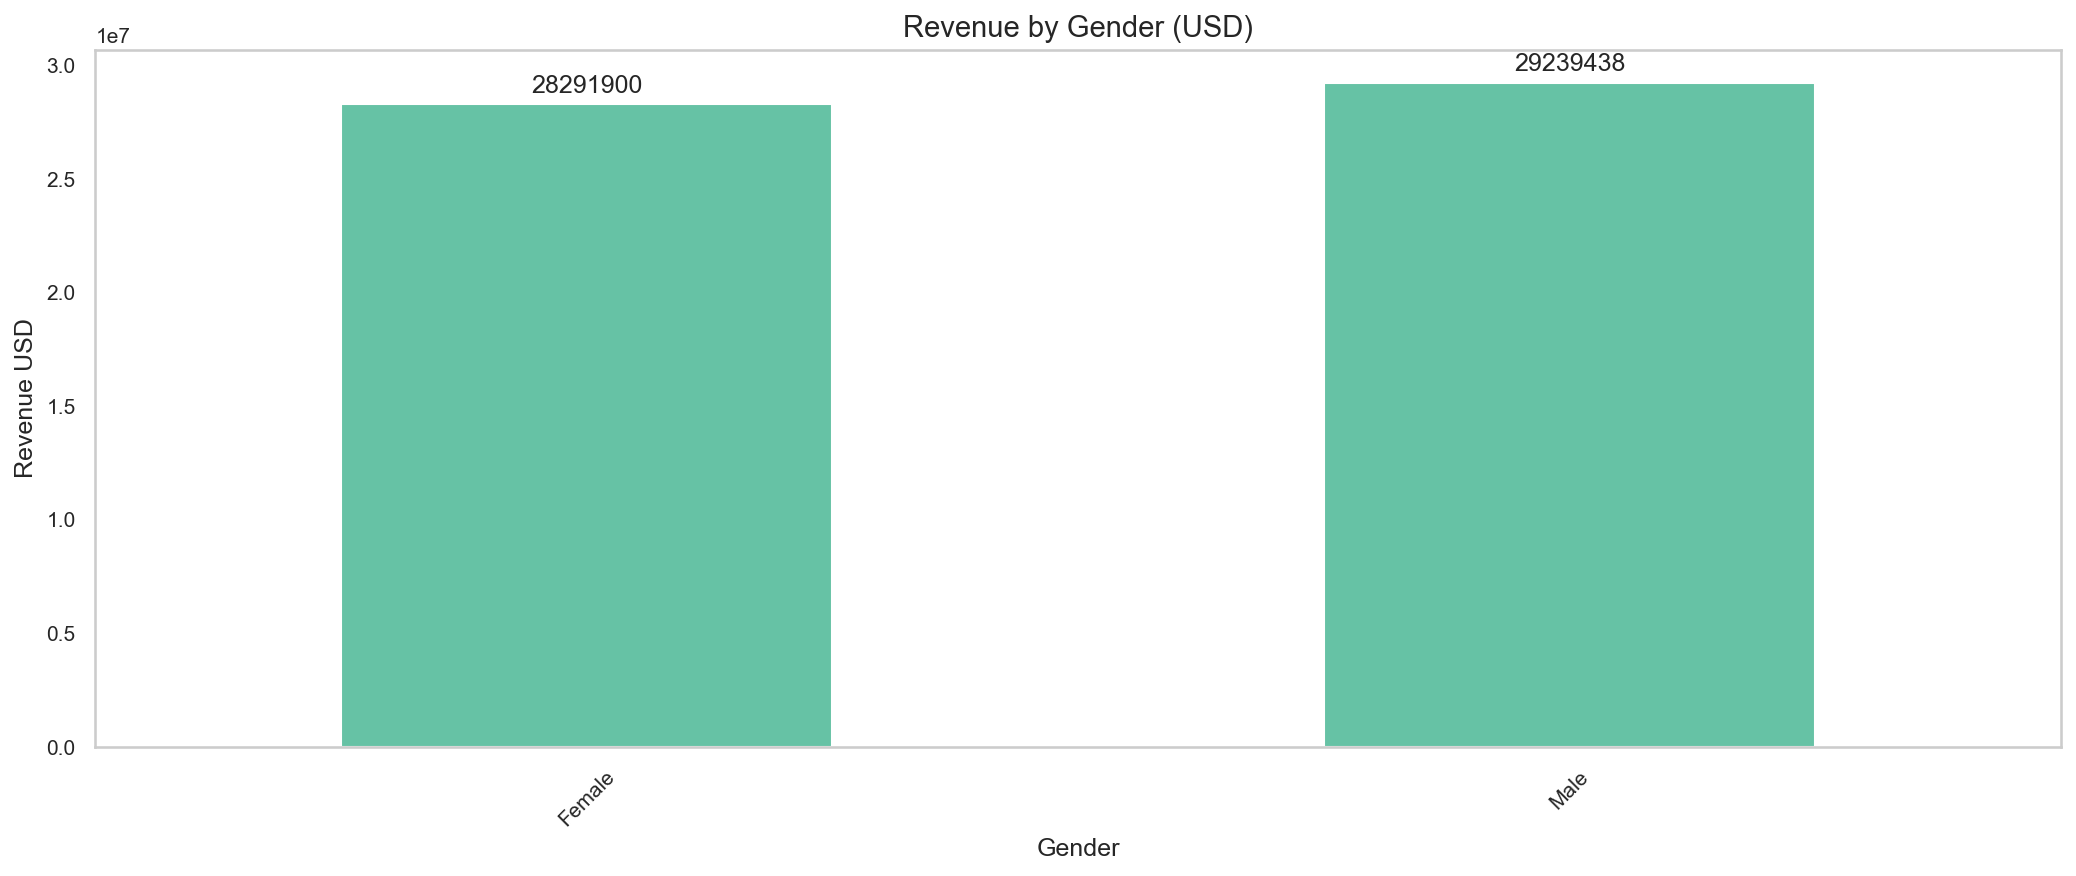

In [4]:
by_gender = revenue_analysis.revenue_by_gender(sales, customers)
display(by_gender)
fig, ax = base.bar(
    by_gender.set_index("Gender")["Revenue USD"],
    title="Revenue by Gender (USD)",
    xlabel="Gender",
    ylabel="Revenue USD",
    filename="revenue_by_gender.png"
)
display(fig)

## Revenue by Continent

,Continent,Revenue USD
2,North America,33464596.63
1,Europe,22121429.67
0,Australia,1945312.16


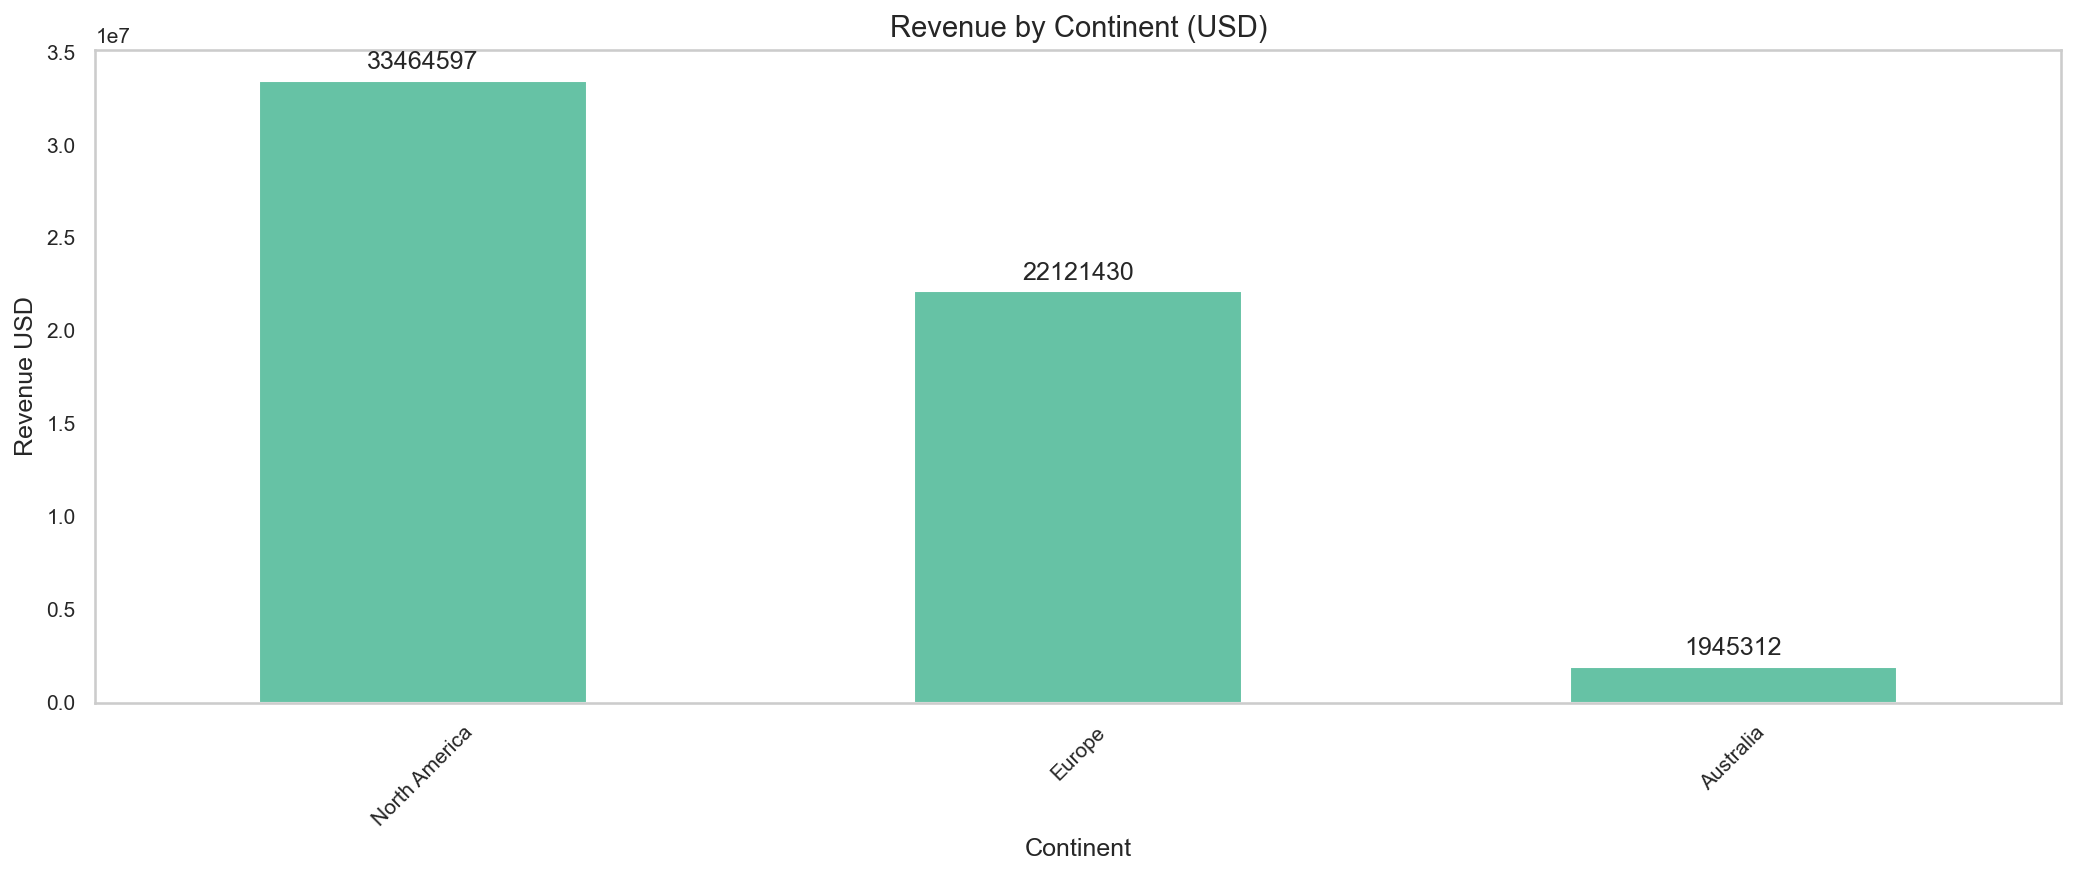

In [5]:
by_continent = revenue_analysis.revenue_by_continent(sales, customers)
display(by_continent)
fig, ax = base.bar(
    by_continent.set_index("Continent")["Revenue USD"],
    title="Revenue by Continent (USD)",
    xlabel="Continent",
    ylabel="Revenue USD",
    filename="revenue_by_continent.png"
)

display(fig)

## Premium vs Standard Products

,Segment,Revenue USD
0,Premium,16180174.05
1,Standard,41351164.41


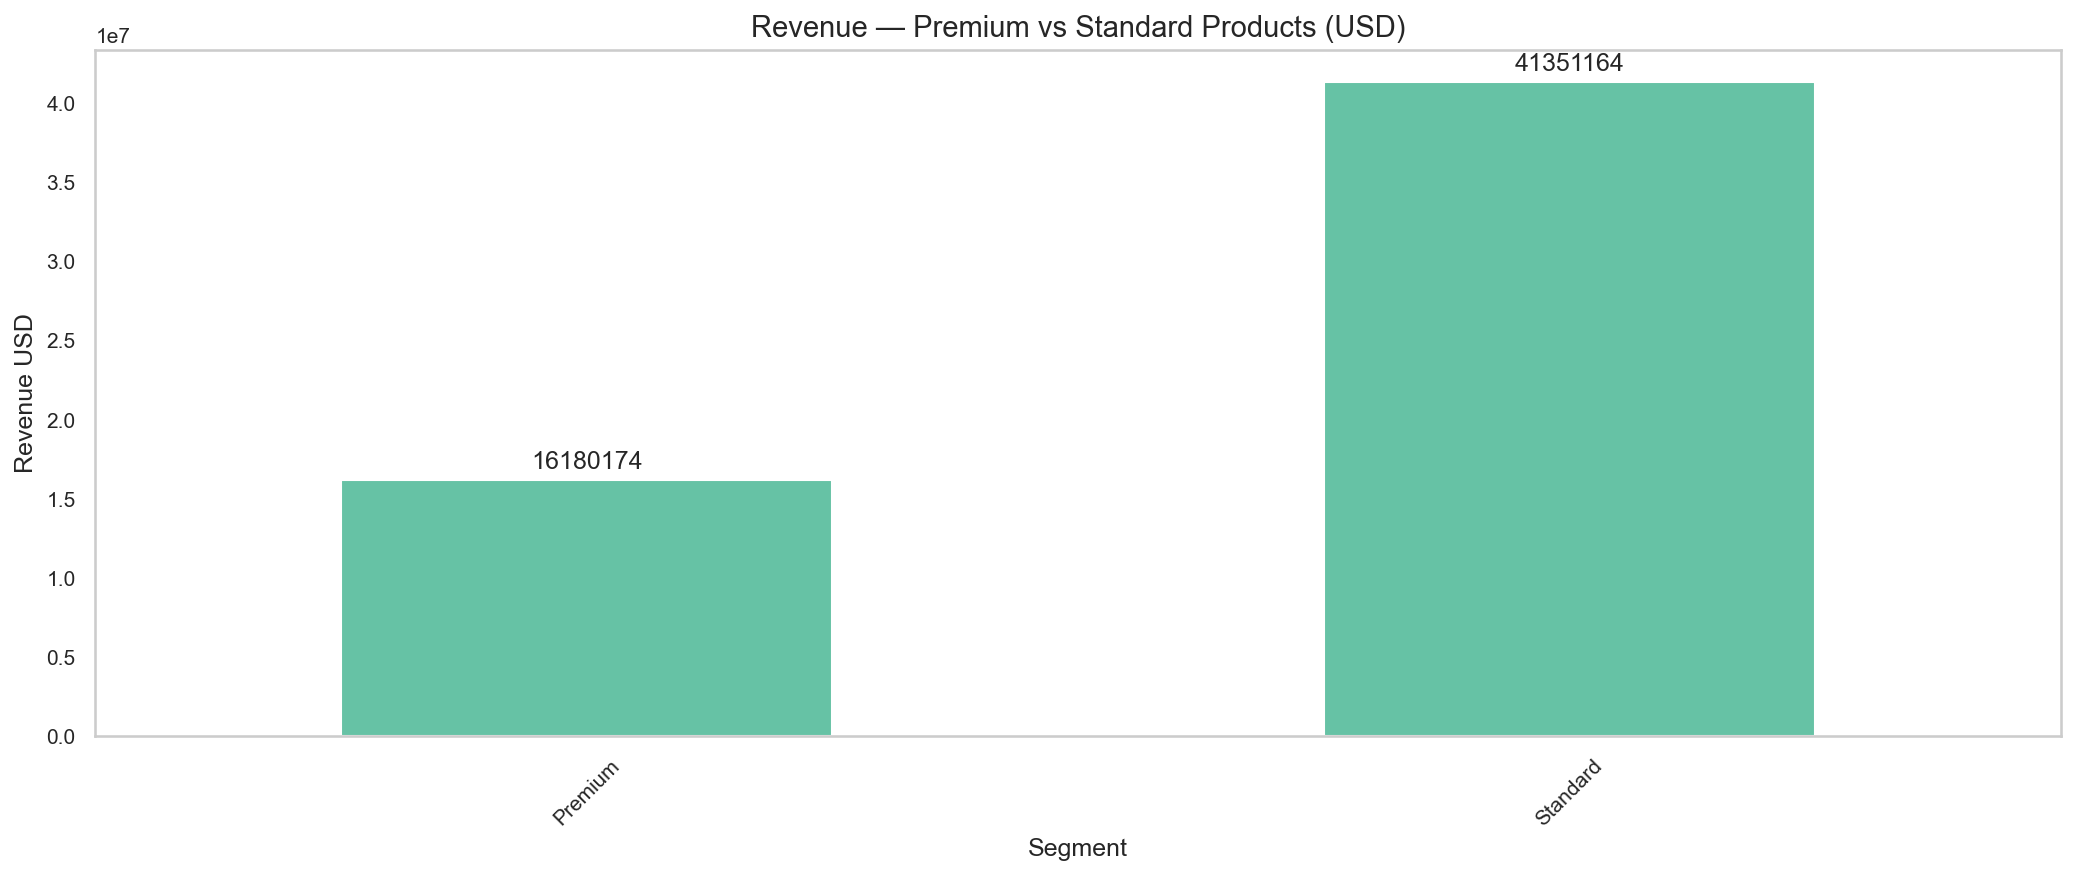

In [6]:
by_segment = revenue_analysis.revenue_premium_vs_standard(sales, products)
display(by_segment)
fig, ax = base.bar(
    by_segment.set_index("Segment")["Revenue USD"],
    title="Revenue — Premium vs Standard Products (USD)",
    xlabel="Segment",
    ylabel="Revenue USD",
    filename="revenue_premium_vs_standard.png"
)

display(fig)

## Bulk vs Standard Orders

,Order Type,Revenue USD
0,Bulk,5218788.44
1,Standard,52312550.02


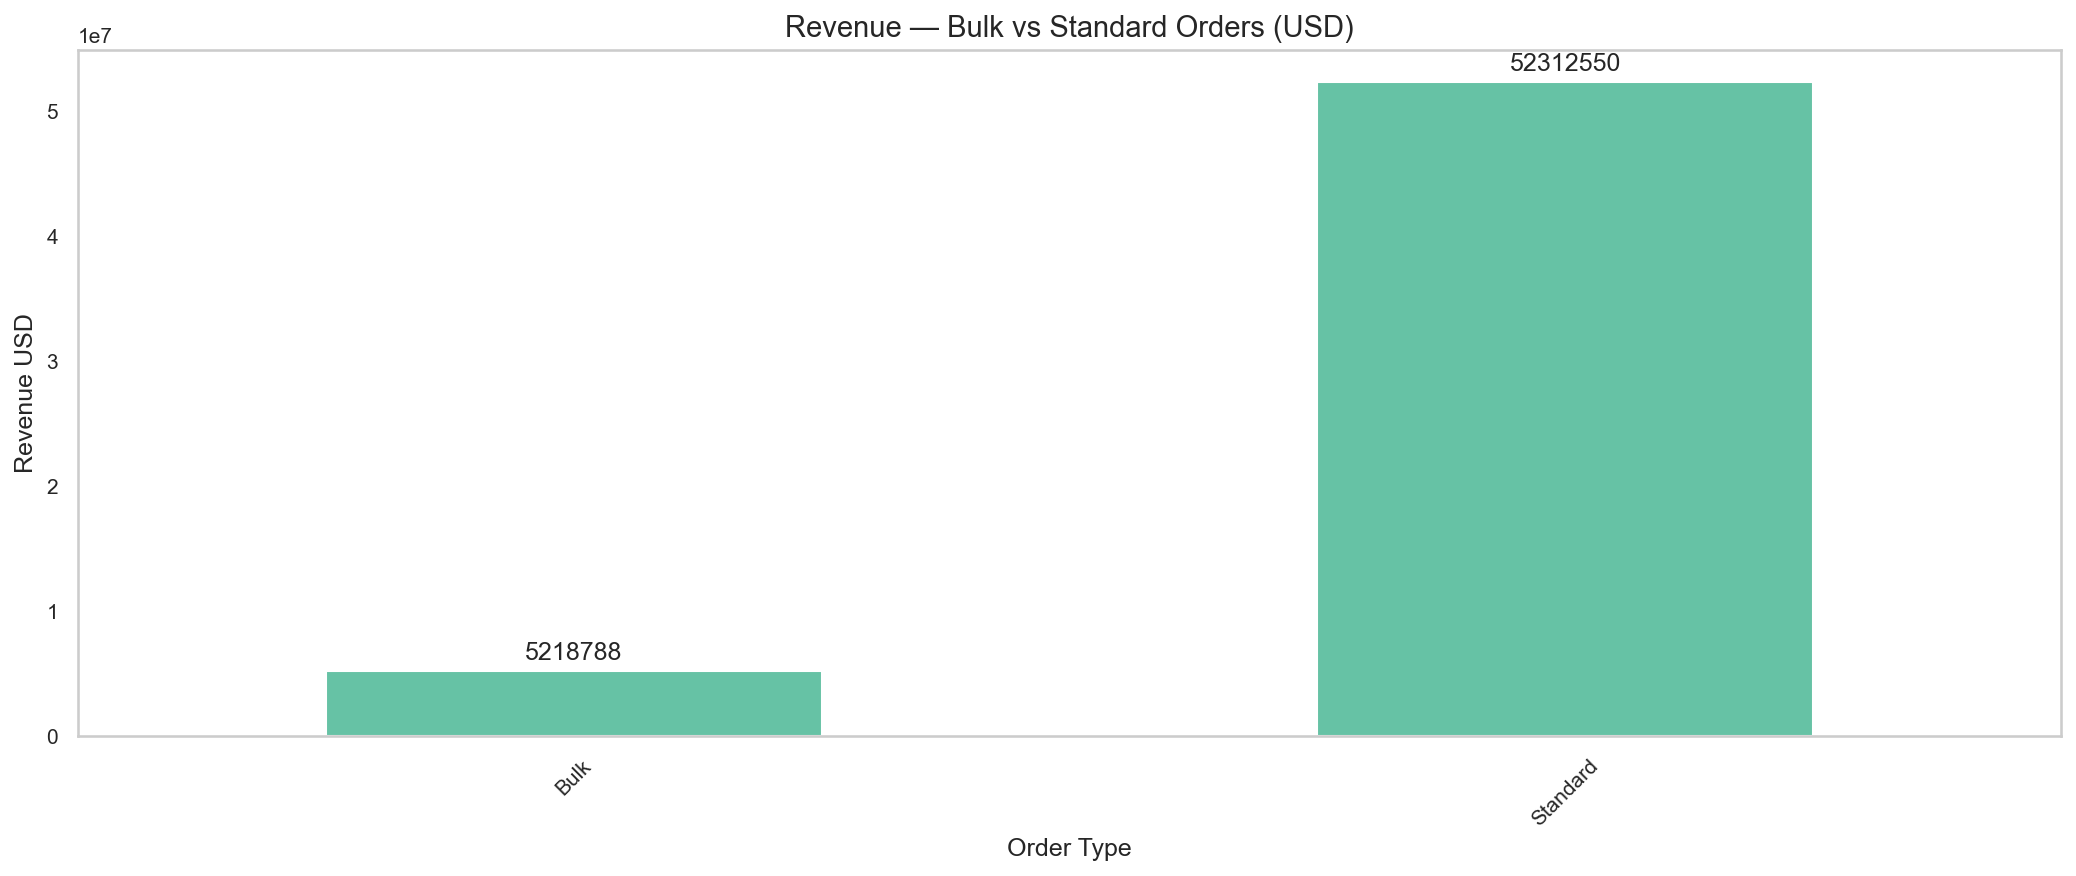

In [7]:
by_order_type = revenue_analysis.revenue_bulk_vs_standard(sales)
display(by_order_type)
fig, ax = base.bar(
    by_order_type.set_index("Order Type")["Revenue USD"],
    title="Revenue — Bulk vs Standard Orders (USD)",
    xlabel="Order Type",
    ylabel="Revenue USD",
    filename="revenue_bulk_vs_standard.png"
)

display(fig)

## Average Order Value by Channel

,Channel,Revenue USD
0,In-Store,922.48
1,Online,886.19


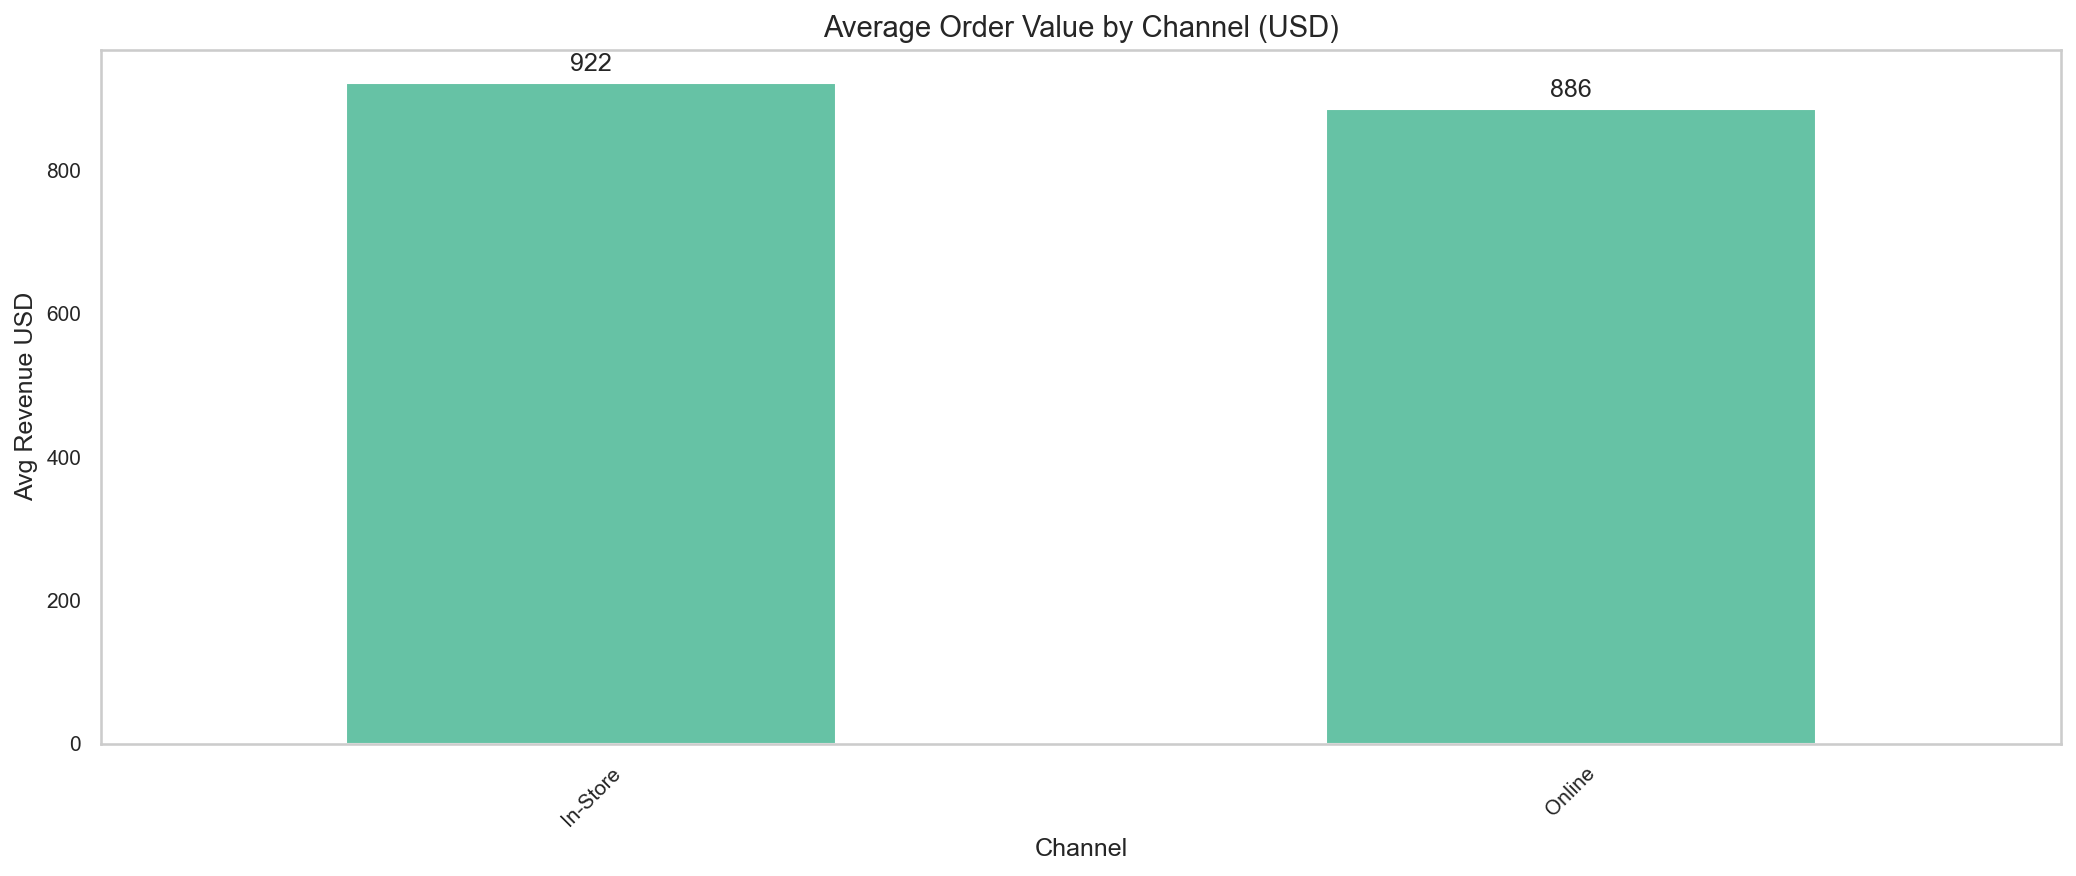

In [8]:
aov_channel = revenue_analysis.avg_order_value_by_channel(sales)
display(aov_channel)
fig, ax = base.bar(
    aov_channel.set_index("Channel")["Revenue USD"],
    title="Average Order Value by Channel (USD)",
    xlabel="Channel",
    ylabel="Avg Revenue USD",
    filename="revenue_aov_by_channel.png"
)

display(fig)

## Average Order Value by Country

,Country,Revenue USD
6,United Kingdom,1133.23
4,Italy,1044.19
3,Germany,1031.94
2,France,994.07
5,Netherlands,989.90
7,United States,884.64
1,Canada,663.52
0,Australia,661.45


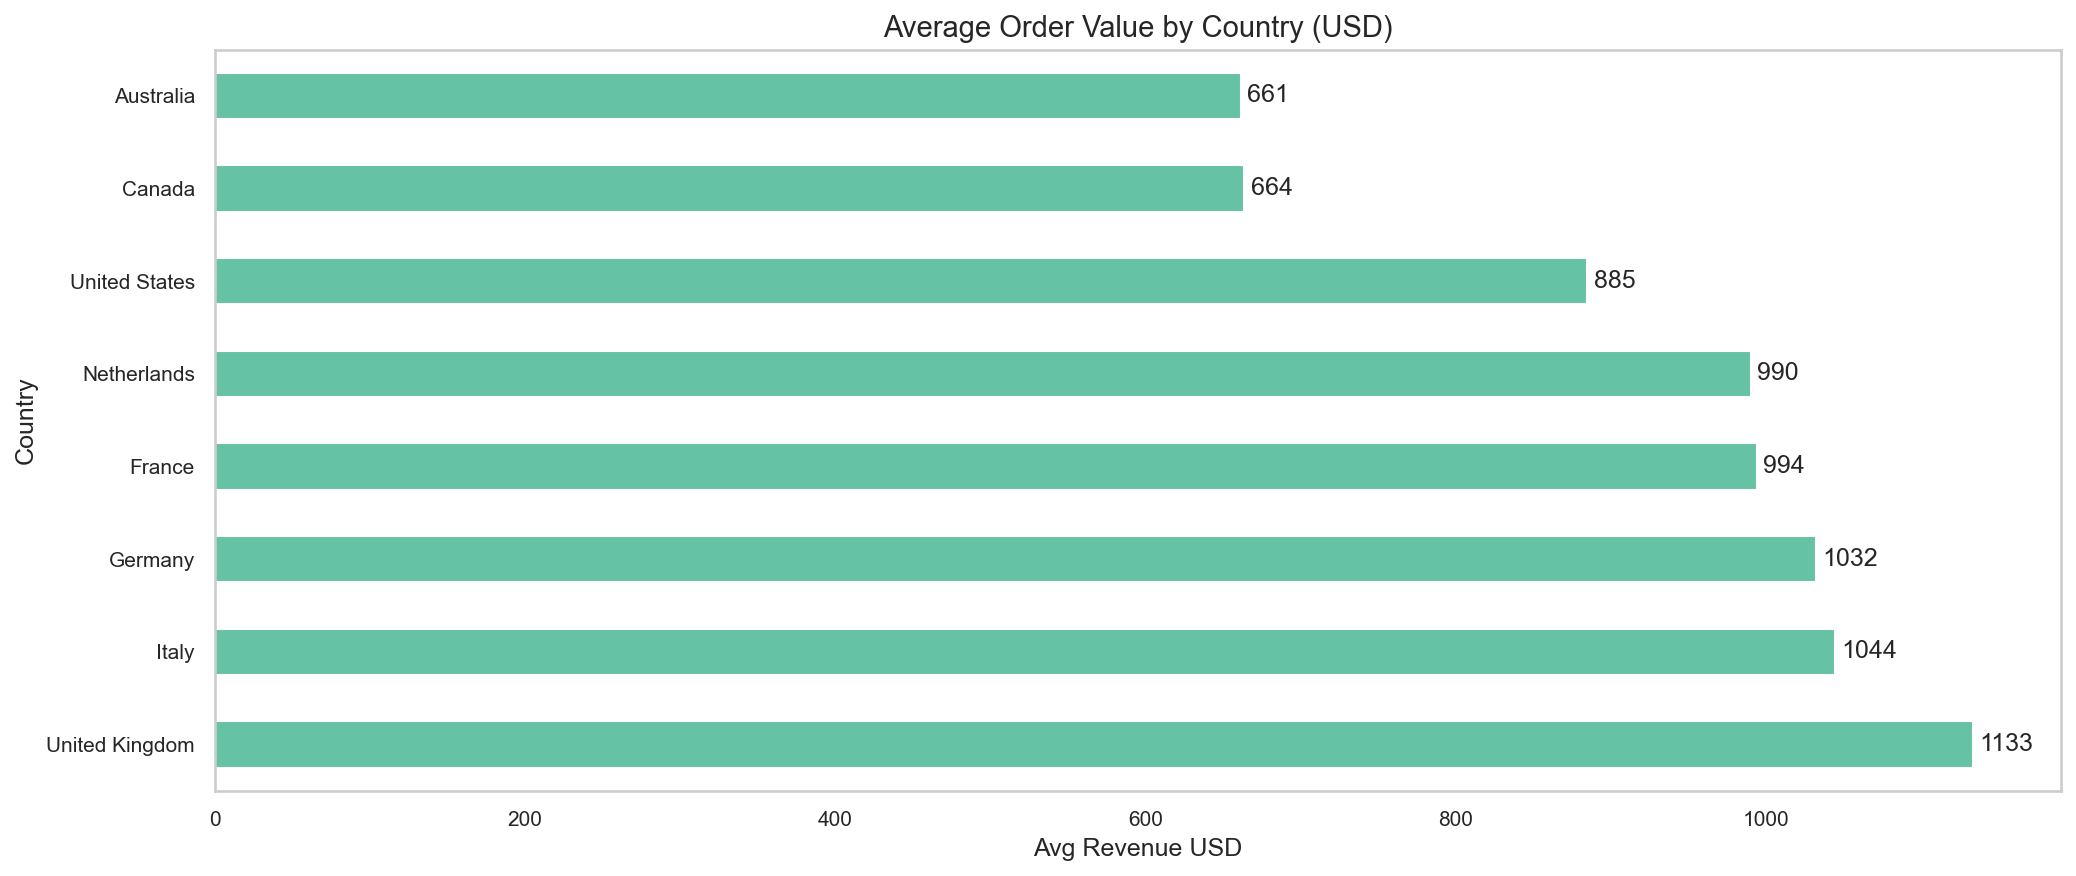

In [9]:
aov_country = revenue_analysis.avg_order_value_by_country(sales, customers)
display(aov_country)
fig, ax = base.horizontal_bar(
    aov_country.set_index("Country")["Revenue USD"],
    title="Average Order Value by Country (USD)",
    xlabel="Avg Revenue USD",
    ylabel="Country",
    filename="revenue_aov_by_country.png"
)

display(fig)

## Quarterly Revenue Trend

,Order Date Year,Order Date Quarter,Revenue USD,Period
0,2016,1,1963836.86,2016 Q1
1,2016,2,1310338.07,2016 Q2
2,2016,3,1620748.56,2016 Q3
3,2016,4,2340836.27,2016 Q4
4,2017,1,1788968.90,2017 Q1
5,2017,2,1349538.75,2017 Q2
6,2017,3,1882338.56,2017 Q3
7,2017,4,2691844.14,2017 Q4
8,2018,1,2900984.34,2018 Q1
9,2018,2,2227810.85,2018 Q2


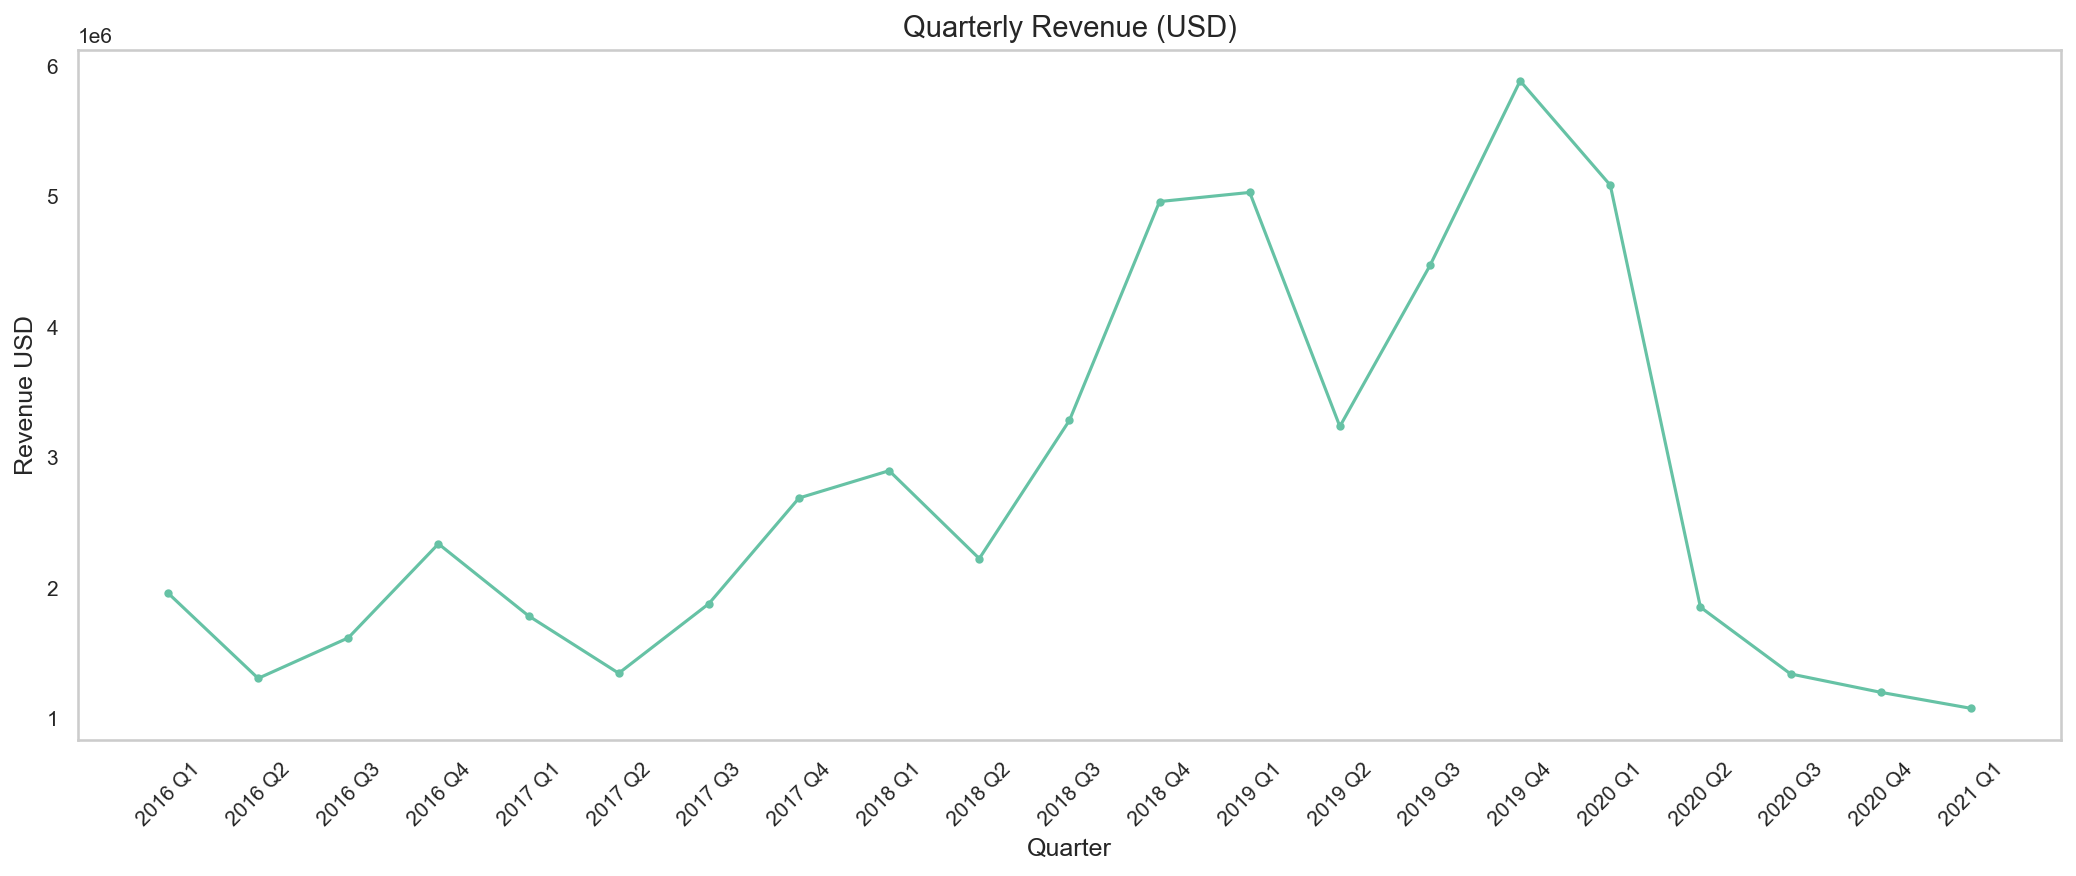

In [10]:
quarterly = revenue_analysis.revenue_by_quarter(sales)
quarterly["Period"] = quarterly["Order Date Year"].astype(str) + " Q" + quarterly["Order Date Quarter"].astype(str)
display(quarterly)
fig, ax = base.line(
    quarterly,
    x="Period",
    y="Revenue USD",
    title="Quarterly Revenue (USD)",
    xlabel="Quarter",
    ylabel="Revenue USD",
    filename="revenue_quarterly.png"
)

display(fig)

## Revenue by Category and Channel

In [11]:
cat_channel = revenue_analysis.revenue_by_category_channel(sales, products)
display(cat_channel)

Channel,In-Store,Online
Category,,
Audio,2592085.57,679226.28
Cameras and camcorders,5416247.12,1278165.60
Cell phones,4991445.74,1403257.76
Computers,15758977.50,4167333.36
Games and Toys,592967.61,154573.27
Home Appliances,8967318.60,2154623.12
"Music, Movies and Audio Books",2577902.56,649626.54
TV and Video,4967731.43,1179856.40


## Revenue Deep Dive — Findings

### Customer Age
- 65+ is the single largest revenue-generating group at $22.2M — nearly double the next group.
- 35-49 ($13.1M) and 50-64 ($12.5M) are close to each other and form the second tier.
- 25-34 contributes $8.8M — decent volume but lower than older groups.
- Under-25 generates just $892K — consistent with their 1% share of the customer base.
- Revenue skews heavily toward older customers. The business has almost no presence with younger buyers.

### Gender
- Male: $29.2M vs Female: $28.3M — a 3% gap, effectively no difference.
- Gender is not a meaningful revenue differentiator in this dataset.

### Geography
| Continent | Revenue | Share |
|-----------|---------|-------|
| North America | $33.5M | 58% |
| Europe | $22.1M | 38% |
| Australia | $1.9M | 3% |

- Business operates in only 3 continents — no presence in Asia, Africa, or South America.
- Australia is significantly underweighted relative to its store count (6 stores, only 3% of revenue).

### Average Order Value by Country
- UK customers spend the most per order at $1,133 — 70% more than Australia ($661).
- European countries (Germany $1,032, Italy $1,044, France $994) all sit above $990.
- Canada ($664) and Australia ($661) are the weakest — both well below the global average.
- US ($885) is mid-range despite dominating on total revenue — driven by volume, not order size.

### Channel AOV
- In-Store: $922 vs Online: $886 — nearly identical.
- Channel does not influence how much a customer spends per order.

### Premium vs Standard Products
- Standard products account for $41.4M (72%) vs Premium at $16.2M (28%).
- Premium products (7.95% of catalogue) punch above their weight — 200 SKUs generating $16.2M.
- Premium revenue per SKU is significantly higher than standard.

### Bulk vs Standard Orders
- Bulk orders (Quantity 9-10) generate $5.2M — just 9% of total revenue despite being 2.88% of orders.
- Bulk order AOV is naturally higher but their overall revenue contribution is modest.
- Not a primary revenue driver — standard single-unit orders carry the business.

### Quarterly Seasonality
- Q4 is consistently the strongest quarter every year — clearest in 2019 Q4 at ~$5.9M peak.
- Q2 is consistently the weakest — visible dip every year from 2016 through 2019.
- Strong Q4 suggests holiday/end-of-year purchasing drives a meaningful spike in electronics sales.
- 2020 Q1 held up well (~$5.1M) before collapsing sharply from Q2 2020 onward.
- 2021 Q1 at ~$1.1M reflects both the partial period and the continued post-2020 decline.